<a href="https://colab.research.google.com/github/bhosalesamir/Codsoft-samir/blob/main/fashion(dl3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 import tensorflow as tf
 from tensorflow.keras import layers, models  # For building the neural network
 import matplotlib.pyplot as plt             # For visualization
 import numpy as np                          # For numerical operations

In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
 X_train = X_train / 255.0  # Normalize pixel values to [0, 1]
 X_test = X_test / 255.0

In [5]:
 model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),       # Flatten 2D image to 1D vector
    layers.Dense(128, activation='relu'),       # Hidden layer with 128 neurons
    layers.Dense(64, activation='relu'),        # Another hidden layer with 64 neurons
    layers.Dense(10, activation='softmax')      # Output layer for 10 classes
 ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
 model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7763 - loss: 0.6393 - val_accuracy: 0.8527 - val_loss: 0.3994
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8606 - loss: 0.3816 - val_accuracy: 0.8657 - val_loss: 0.3657
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8756 - loss: 0.3383 - val_accuracy: 0.8762 - val_loss: 0.3425
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8848 - loss: 0.3085 - val_accuracy: 0.8703 - val_loss: 0.3377
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8890 - loss: 0.2959 - val_accuracy: 0.8788 - val_loss: 0.3337
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8964 - loss: 0.2789 - val_accuracy: 0.8887 - val_loss: 0.3171
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8980 - loss: 0.2715 - val_accuracy: 0.8823 - val_loss: 0.3345
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9035 - loss: 0.2554 

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8803 - loss: 0.3552
Test Accuracy: 0.8785


In [9]:
 predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


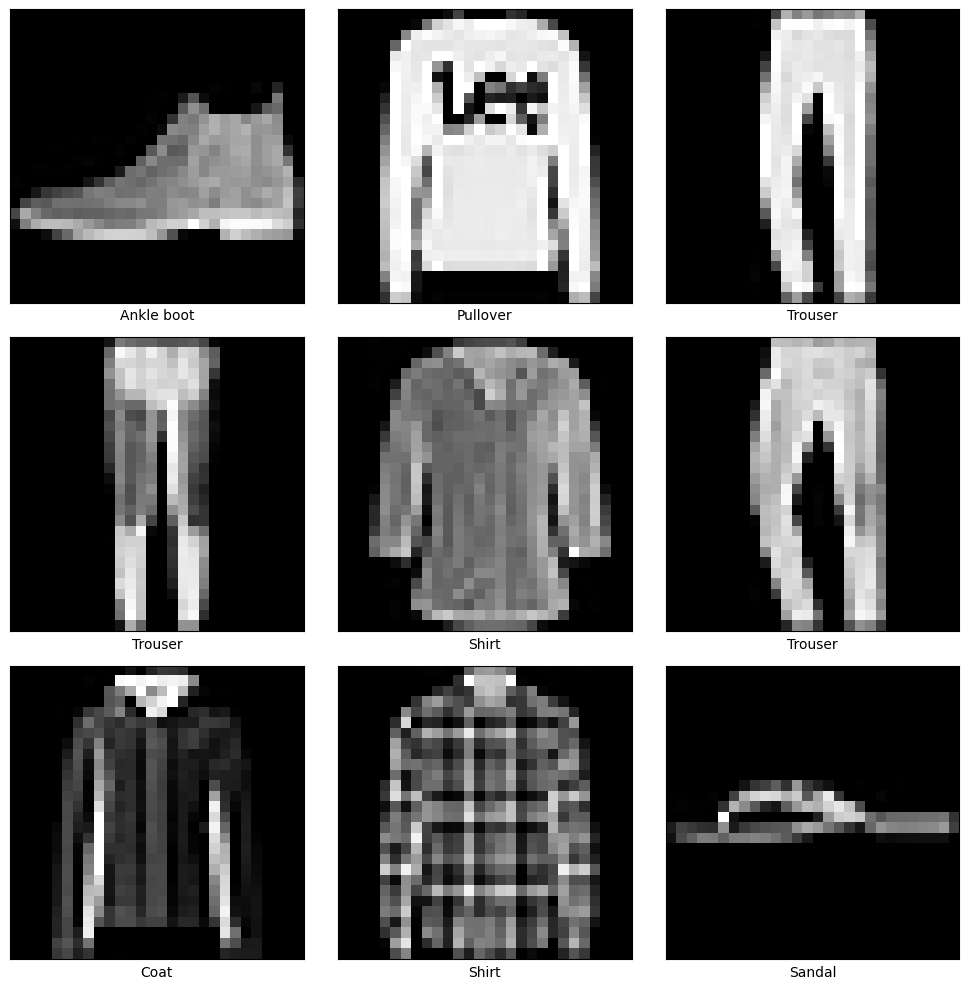

In [10]:
 class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
 plt.figure(figsize=(10,10))
 for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[i], cmap='gray')
    plt.xlabel(class_names[np.argmax(predictions[i])])
 plt.tight_layout()
 plt.show()